In [35]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
from persiantools.jdatetime import JalaliDate
import jalali_pandas
import pandas_ta  as ta

In [36]:
df = pd.read_csv(r'../data/RMCI.csv', encoding='utf-8')
df.head()

,ticker,miladi,open,high,low,close,volume,value,transaction_count,lastday_price,shamsi
0,همراه,20130820,42000.0,42200.0,42000.0,42001.0,546520,2.295462e+10,69,1000.0,13920529
1,همراه,20130821,42009.0,43500.0,42005.0,42142.0,161499,6.929039e+09,214,42001.0,13920530
2,همراه,20130824,43300.0,43300.0,42222.0,42191.0,110913,4.724576e+09,168,42142.0,13920602
3,همراه,20130825,42860.0,42860.0,42453.0,42213.0,67490,2.869908e+09,94,42191.0,13920603
4,همراه,20130826,42401.0,42501.0,42036.0,42214.0,160307,6.768045e+09,121,42213.0,13920604


In [37]:
df['Gregorian_Date'] = pd.to_datetime(df['miladi'], format='%Y%m%d')
df["Jalali_Date"] = df["Gregorian_Date"].jalali.to_jalali()
df['year'] = df["Jalali_Date"].jalali.year
df['month'] = df["Jalali_Date"].jalali.month
df['day'] = df["Jalali_Date"].jalali.day
df['weekday'] = df["Jalali_Date"].jalali.weekday
df.drop(['ticker','shamsi','miladi'],axis=1,inplace=True)
df['price_change'] = df['close'] - df['open']

# Calculate daily returns
df['daily_return'] = (df['close'] - df['lastday_price']) / df['lastday_price']

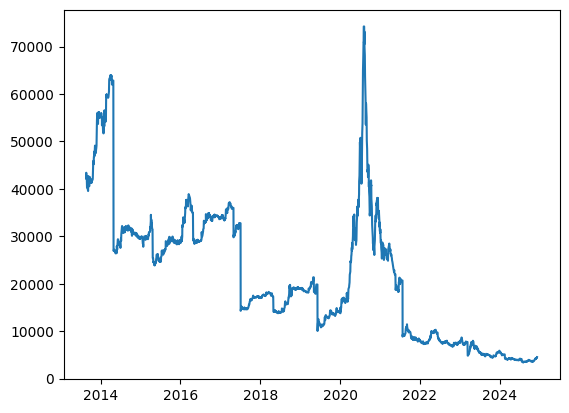

In [4]:
plt.plot(df['Gregorian_Date'],df['last_price'])

In [38]:
df['Jalali_Date_Str'] = df['Jalali_Date'].apply(lambda x: x.strftime('%Y-%m-%d'))

# Adjust figure size
plt.figure(figsize=(14, 5))  # Width: 16, Height: 8

# Plotting the data
plt.plot(df['Jalali_Date_Str'], df['last_price'])

# Set x-axis ticks to show every 50th data point
x_ticks_indices = range(0, len(df['Jalali_Date_Str']), 50)  # Every 50th index
x_ticks_labels = df['Jalali_Date_Str'].iloc[x_ticks_indices]
plt.xticks(ticks=x_ticks_indices, labels=x_ticks_labels, rotation=45)

# Add labels and title
plt.xlabel('Jalali Date (Every 50th)')
plt.ylabel('last price Values')  # Replace <COL15> with a descriptive label
plt.title('Line Plot with Jalali Dates (Every 50th Tick)')

# Display the plot
plt.show()

KeyError: 'last_price'

<Figure size 1400x500 with 0 Axes>

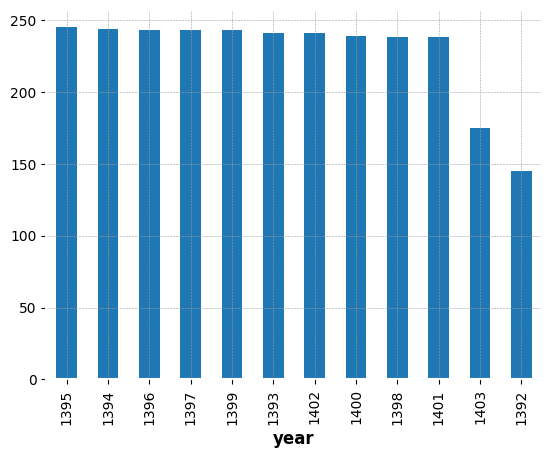

In [39]:
df['year'].value_counts().plot(kind='bar')
plt.show()

In [40]:
yearly_diff = (
    df.groupby('year')['last_price']  # Group by year
    .agg(['first', 'last'])  # Get the first and last values for each year
    .eval('Difference = last - first')  # Calculate the difference
    .reset_index()  # Reset index for plotting
)

plt.figure(figsize=(12, 6))
bars = plt.bar(yearly_diff['year'], yearly_diff['Difference'], color='skyblue')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # X coordinate
        height,  # Y coordinate (height of the bar)
        f'{height:.2f}',  # Format the value
        ha='center',  # Horizontal alignment
        va='bottom',  # Vertical alignment
        fontsize=10  # Font size
    )

# Customize the chart
plt.xlabel('Year')
plt.ylabel('Difference in last price')
plt.title('Yearly Difference in last price')
plt.xticks(yearly_diff['year'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()

KeyError: 'Column not found: last_price'

In [41]:
monthly_diff = (
    df.groupby(['year', 'month'])['last_price']  # Group by year and month
    .agg(['first', 'last'])  # Get the first and last values for each group
    .eval('Difference = last - first')  # Calculate the difference
    .reset_index()  # Reset index for plotting
)

# Create a combined "Year-Month" column for better visualization on the x-axis
monthly_diff['Year-Month'] = monthly_diff['year'].astype(str) + '-' + monthly_diff['month'].astype(str).str.zfill(2)

# Adjust figure size
plt.figure(figsize=(14, 7))

plt.plot(
    monthly_diff['Year-Month'], 
    monthly_diff['Difference'], 
    color='orange', 
    marker='o', 
    label='Trend Line'
)

plt.xlabel('Year-Month')
plt.ylabel('Difference in last price')
plt.title('Monthly Difference in last price')
plt.xticks(
    range(0, len(monthly_diff['Year-Month']), 3),  # Show every 3rd label for readability
    monthly_diff['Year-Month'][::3], 
    rotation=45
)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

KeyError: 'Column not found: last_price'

In [42]:
df.head(10)

,open,high,low,close,volume,value,transaction_count,lastday_price,Gregorian_Date,Jalali_Date,year,month,day,weekday,price_change,daily_return,Jalali_Date_Str
0,42000.0,42200.0,42000.0,42001.0,546520,2.295462e+10,69,1000.0,2013-08-20,1392-05-29 00:00:00,1392,5,29,3,1.0,41.001000,1392-05-29
1,42009.0,43500.0,42005.0,42142.0,161499,6.929039e+09,214,42001.0,2013-08-21,1392-05-30 00:00:00,1392,5,30,4,133.0,0.003357,1392-05-30
2,43300.0,43300.0,42222.0,42191.0,110913,4.724576e+09,168,42142.0,2013-08-24,1392-06-02 00:00:00,1392,6,2,0,-1109.0,0.001163,1392-06-02
3,42860.0,42860.0,42453.0,42213.0,67490,2.869908e+09,94,42191.0,2013-08-25,1392-06-03 00:00:00,1392,6,3,1,-647.0,0.000521,1392-06-03
4,42401.0,42501.0,42036.0,42214.0,160307,6.768045e+09,121,42213.0,2013-08-26,1392-06-04 00:00:00,1392,6,4,2,-187.0,0.000024,1392-06-04
5,42000.0,42000.0,40900.0,41939.0,303026,1.250767e+10,183,42214.0,2013-08-27,1392-06-05 00:00:00,1392,6,5,3,-61.0,-0.006514,1392-06-05
6,40262.0,40400.0,40262.0,41764.0,107648,4.334256e+09,166,41939.0,2013-08-28,1392-06-06 00:00:00,1392,6,6,4,1502.0,-0.004173,1392-06-06
7,40200.0,40500.0,40094.0,41646.0,75569,3.034039e+09,149,41764.0,2013-08-31,1392-06-09 00:00:00,1392,6,9,0,1446.0,-0.002825,1392-06-09
8,40000.0,40749.0,40000.0,41586.0,55535,2.250627e+09,121,41646.0,2013-09-01,1392-06-10 00:00:00,1392,6,10,1,1586.0,-0.001441,1392-06-10
9,40080.0,40249.0,40002.0,41488.0,64712,2.590272e+09,106,41586.0,2013-09-03,1392-06-12 00:00:00,1392,6,12,3,1408.0,-0.002357,1392-06-12


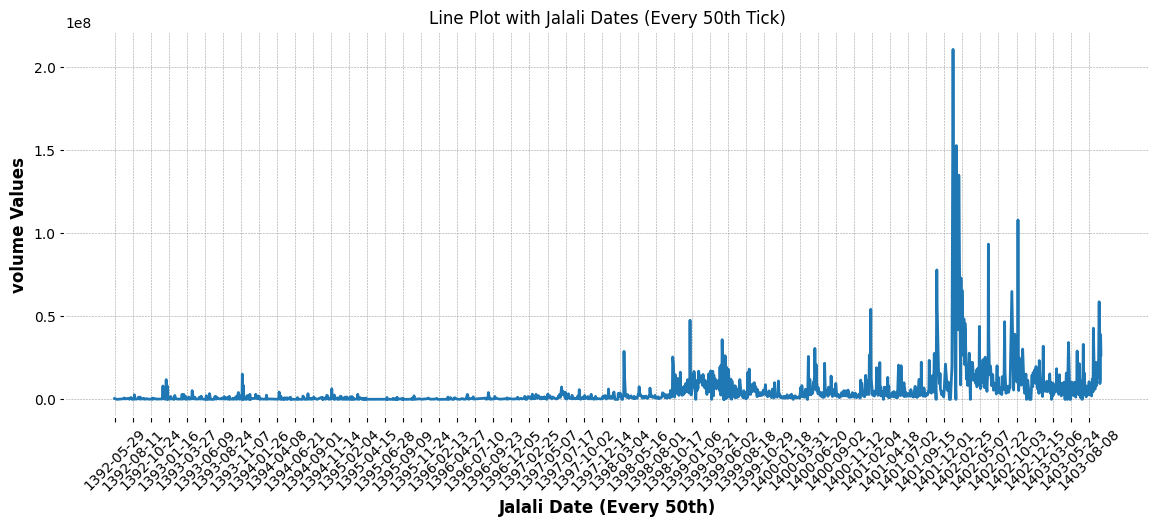

In [43]:
plt.figure(figsize=(14, 5))  # Width: 16, Height: 8

# Plotting the data
plt.plot(df['Jalali_Date_Str'], df['volume'])

# Set x-axis ticks to show every 50th data point
x_ticks_indices = range(0, len(df['Jalali_Date_Str']), 50)  # Every 50th index
x_ticks_labels = df['Jalali_Date_Str'].iloc[x_ticks_indices]
plt.xticks(ticks=x_ticks_indices, labels=x_ticks_labels, rotation=45)

# Add labels and title
plt.xlabel('Jalali Date (Every 50th)')
plt.ylabel('volume Values')  # Replace <COL15> with a descriptive label
plt.title('Line Plot with Jalali Dates (Every 50th Tick)')

# Display the plot
plt.show()

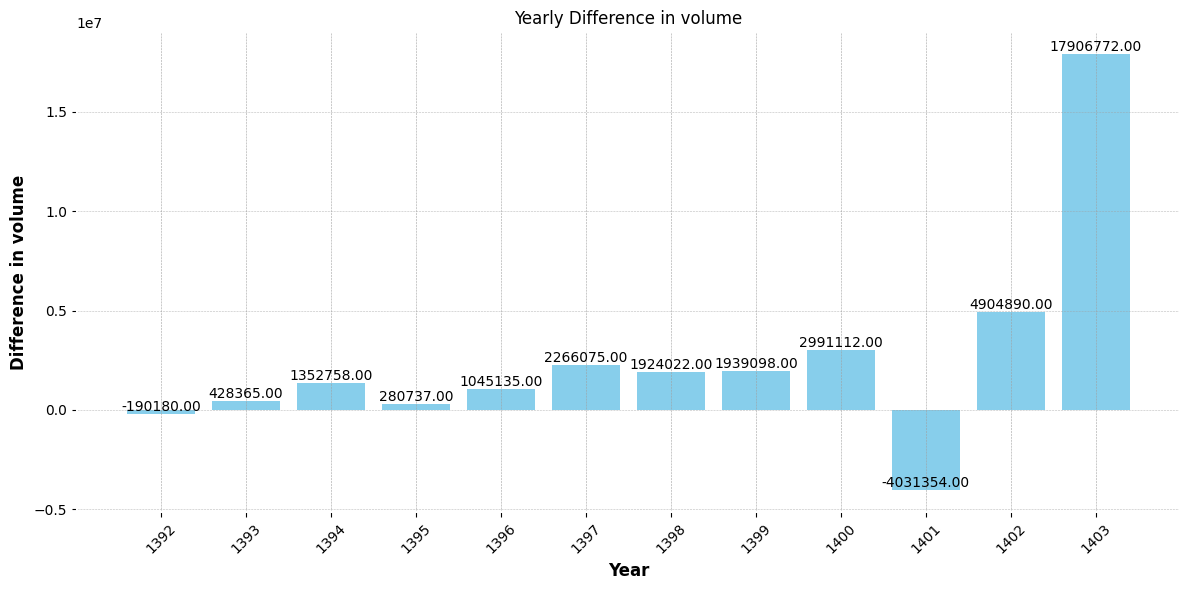

In [44]:
yearly_diff = (
    df.groupby('year')['volume']  # Group by year
    .agg(['first', 'last'])  # Get the first and last values for each year
    .eval('Difference = last - first')  # Calculate the difference
    .reset_index()  # Reset index for plotting
)

plt.figure(figsize=(12, 6))
bars = plt.bar(yearly_diff['year'], yearly_diff['Difference'], color='skyblue')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # X coordinate
        height,  # Y coordinate (height of the bar)
        f'{height:.2f}',  # Format the value
        ha='center',  # Horizontal alignment
        va='bottom',  # Vertical alignment
        fontsize=10  # Font size
    )

# Customize the chart
plt.xlabel('Year')
plt.ylabel('Difference in volume')
plt.title('Yearly Difference in volume')
plt.xticks(yearly_diff['year'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()

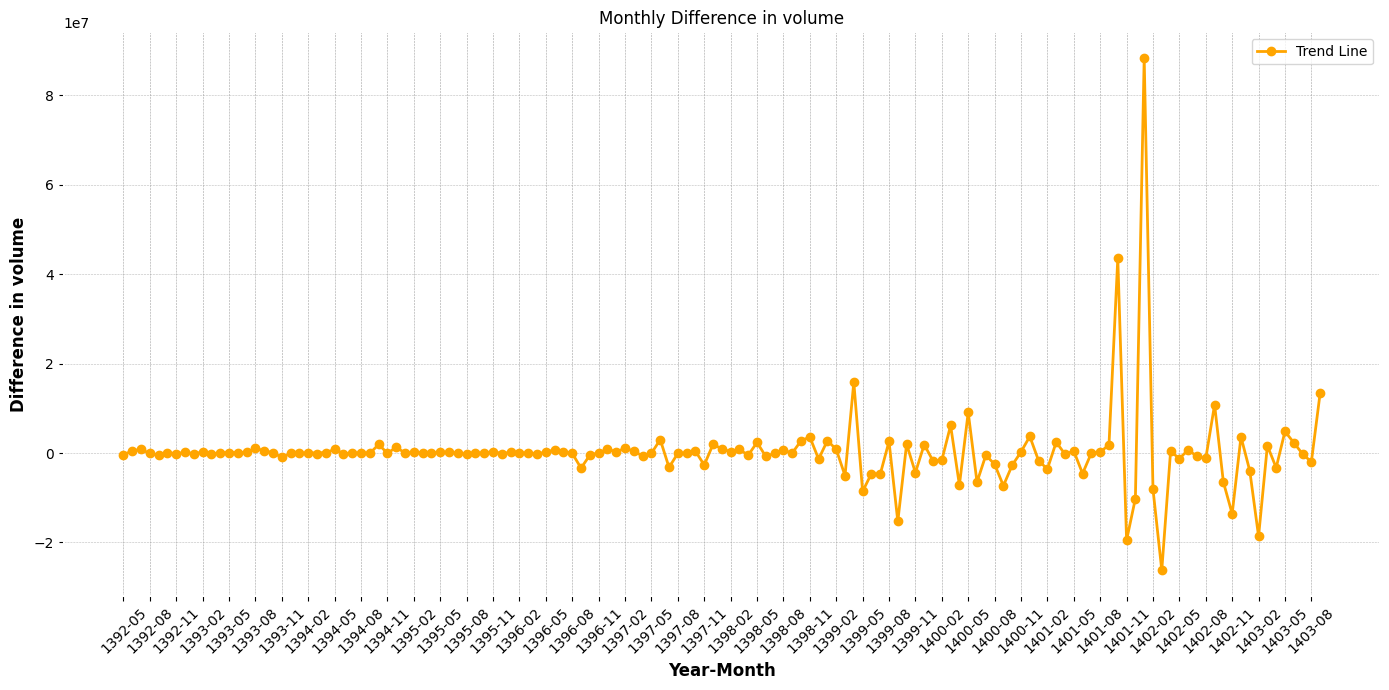

In [45]:
monthly_diff = (
    df.groupby(['year', 'month'])['volume']  # Group by year and month
    .agg(['first', 'last'])  # Get the first and last values for each group
    .eval('Difference = last - first')  # Calculate the difference
    .reset_index()  # Reset index for plotting
)

# Create a combined "Year-Month" column for better visualization on the x-axis
monthly_diff['Year-Month'] = monthly_diff['year'].astype(str) + '-' + monthly_diff['month'].astype(str).str.zfill(2)

# Adjust figure size
plt.figure(figsize=(14, 7))

plt.plot(
    monthly_diff['Year-Month'], 
    monthly_diff['Difference'], 
    color='orange', 
    marker='o', 
    label='Trend Line'
)

plt.xlabel('Year-Month')
plt.ylabel('Difference in volume')
plt.title('Monthly Difference in volume')
plt.xticks(
    range(0, len(monthly_diff['Year-Month']), 3),  # Show every 3rd label for readability
    monthly_diff['Year-Month'][::3], 
    rotation=45
)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

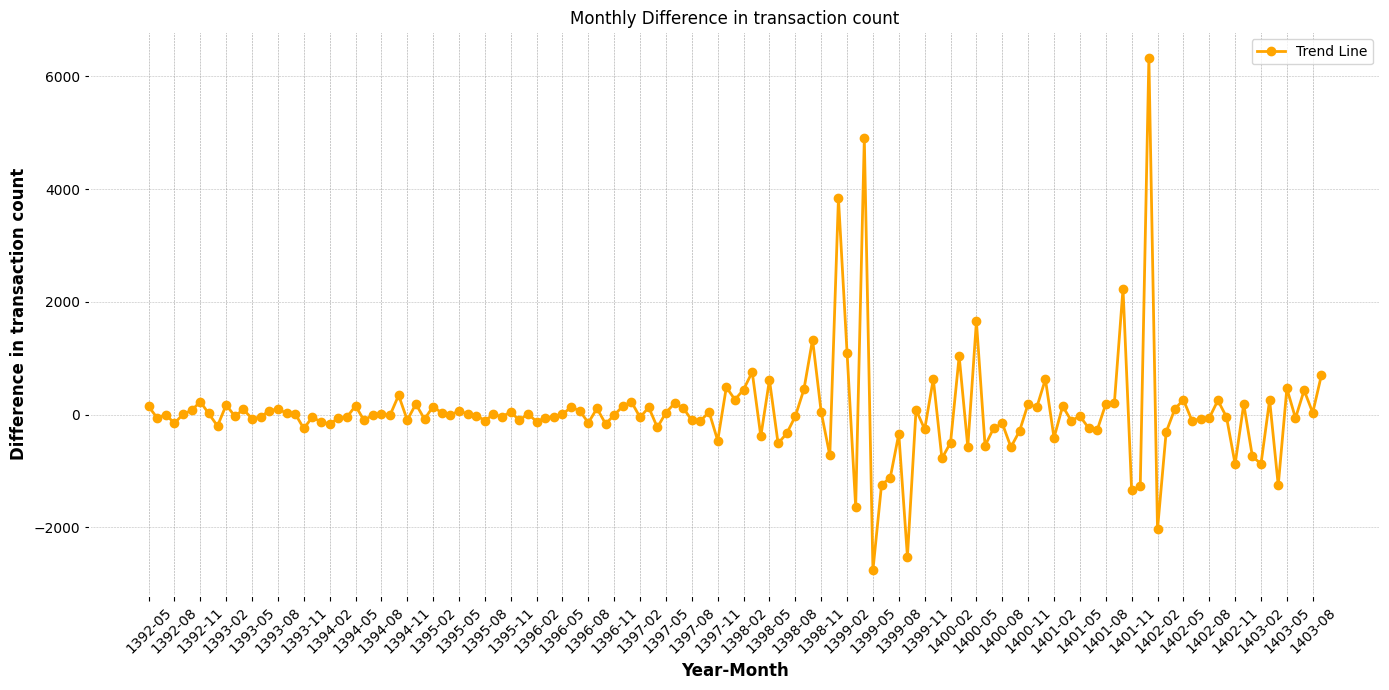

In [46]:
monthly_diff = (
    df.groupby(['year', 'month'])['transaction_count']  # Group by year and month
    .agg(['first', 'last'])  # Get the first and last values for each group
    .eval('Difference = last - first')  # Calculate the difference
    .reset_index()  # Reset index for plotting
)

# Create a combined "Year-Month" column for better visualization on the x-axis
monthly_diff['Year-Month'] = monthly_diff['year'].astype(str) + '-' + monthly_diff['month'].astype(str).str.zfill(2)

# Adjust figure size
plt.figure(figsize=(14, 7))

plt.plot(
    monthly_diff['Year-Month'], 
    monthly_diff['Difference'], 
    color='orange', 
    marker='o', 
    label='Trend Line'
)

plt.xlabel('Year-Month')
plt.ylabel('Difference in transaction count')
plt.title('Monthly Difference in transaction count')
plt.xticks(
    range(0, len(monthly_diff['Year-Month']), 3),  # Show every 3rd label for readability
    monthly_diff['Year-Month'][::3], 
    rotation=45
)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

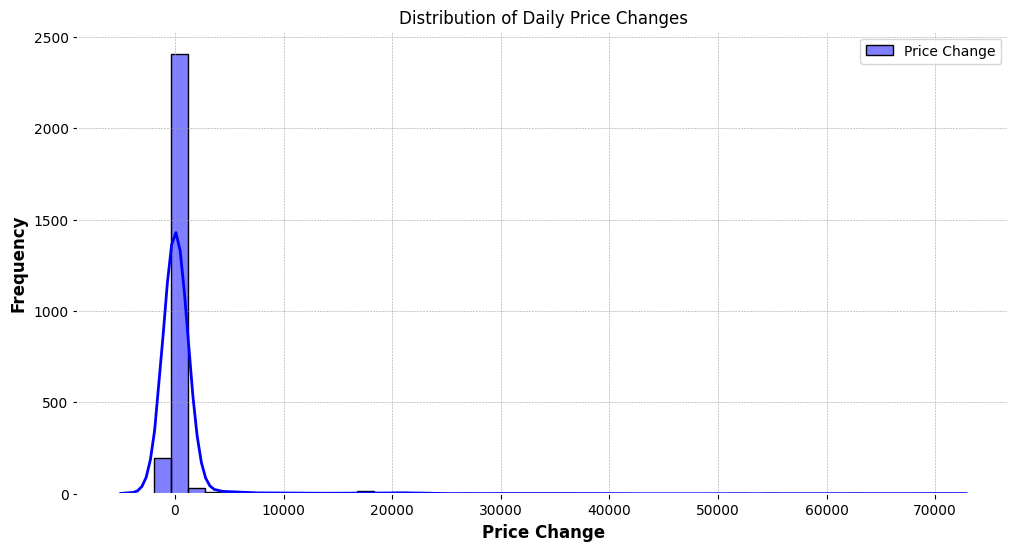

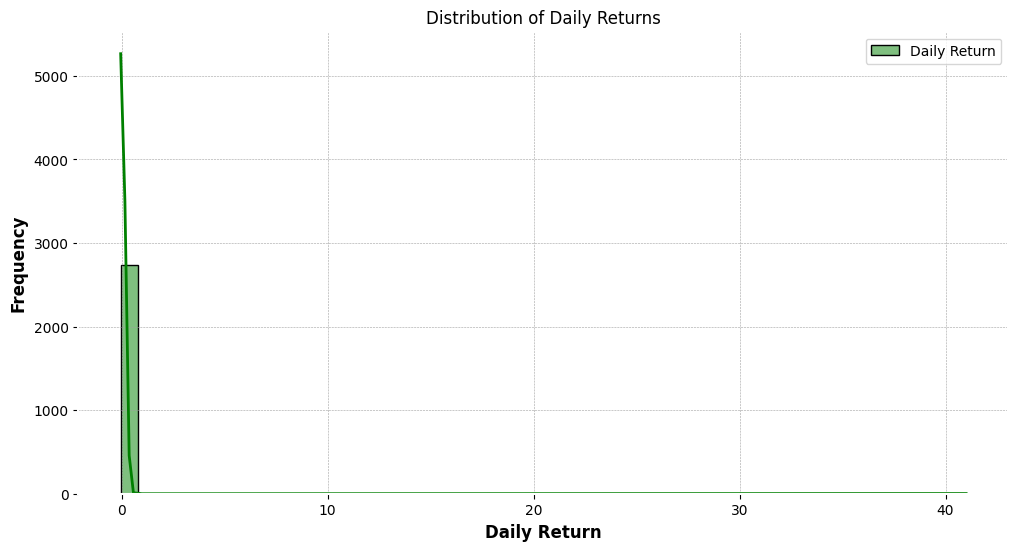

In [47]:
plt.figure(figsize=(12, 6))
sns.histplot(df['price_change'].dropna(), bins=50, kde=True, color='blue', label='Price Change')
plt.title('Distribution of Daily Price Changes')
plt.xlabel('Price Change')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Plot the distribution of daily returns
plt.figure(figsize=(12, 6))
sns.histplot(df['daily_return'].dropna(), bins=50, kde=True, color='green', label='Daily Return')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

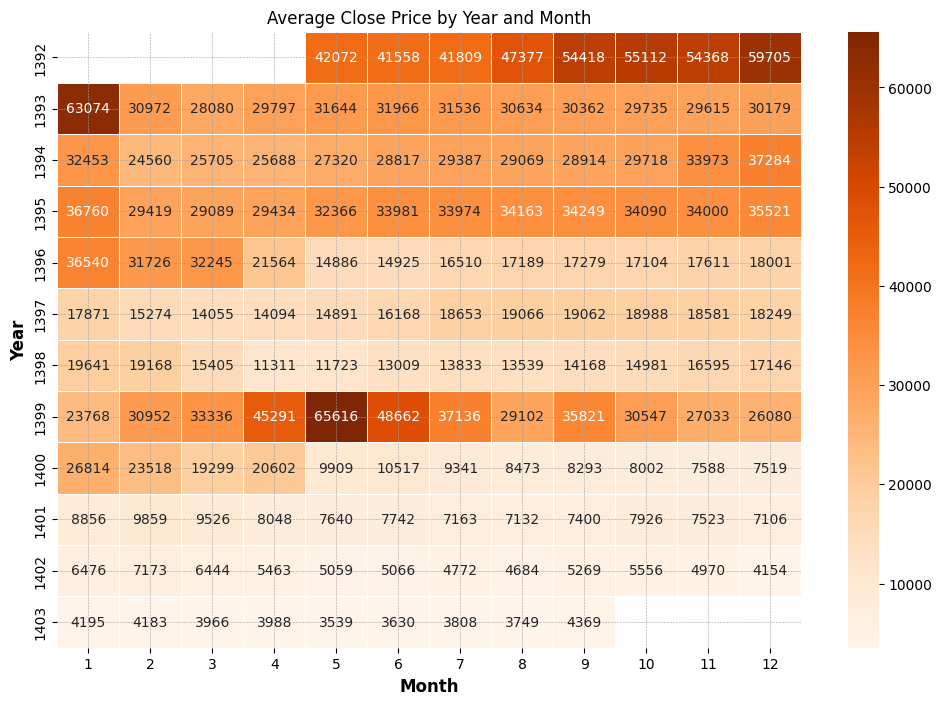

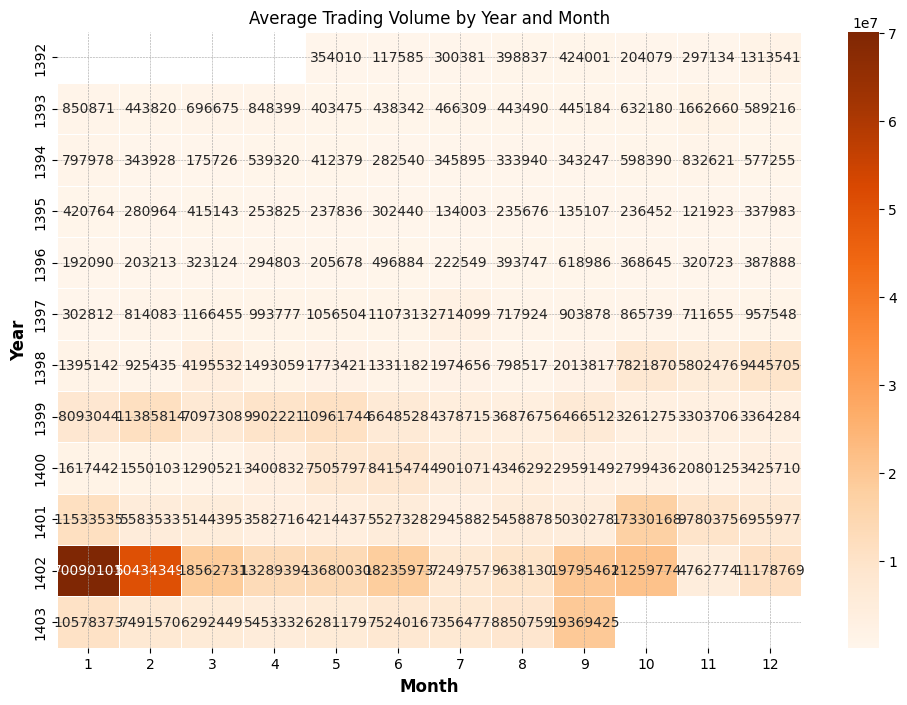

In [48]:

# --- Average Close Price Heatmap ---
# Group by year and month, then calculate the mean of 'close'
average_close = df.groupby(['year', 'month'])['close'].mean().reset_index()

# Pivot the table to create a format suitable for heatmap
heatmap_data_close = average_close.pivot(index='year', columns='month', values='close')

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_close, cmap='Oranges', annot=True, fmt=".0f", linewidths=0.5)
plt.title('Average Close Price by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

# --- Average Trading Volume Heatmap ---
# Group by year and month, then calculate the mean of 'volume'
average_volume = df.groupby(['year', 'month'])['volume'].mean().reset_index()

# Pivot the table for heatmap
heatmap_data_volume = average_volume.pivot(index='year', columns='month', values='volume')

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_volume, cmap='Oranges', annot=True, fmt=".0f", linewidths=0.5)
plt.title('Average Trading Volume by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()


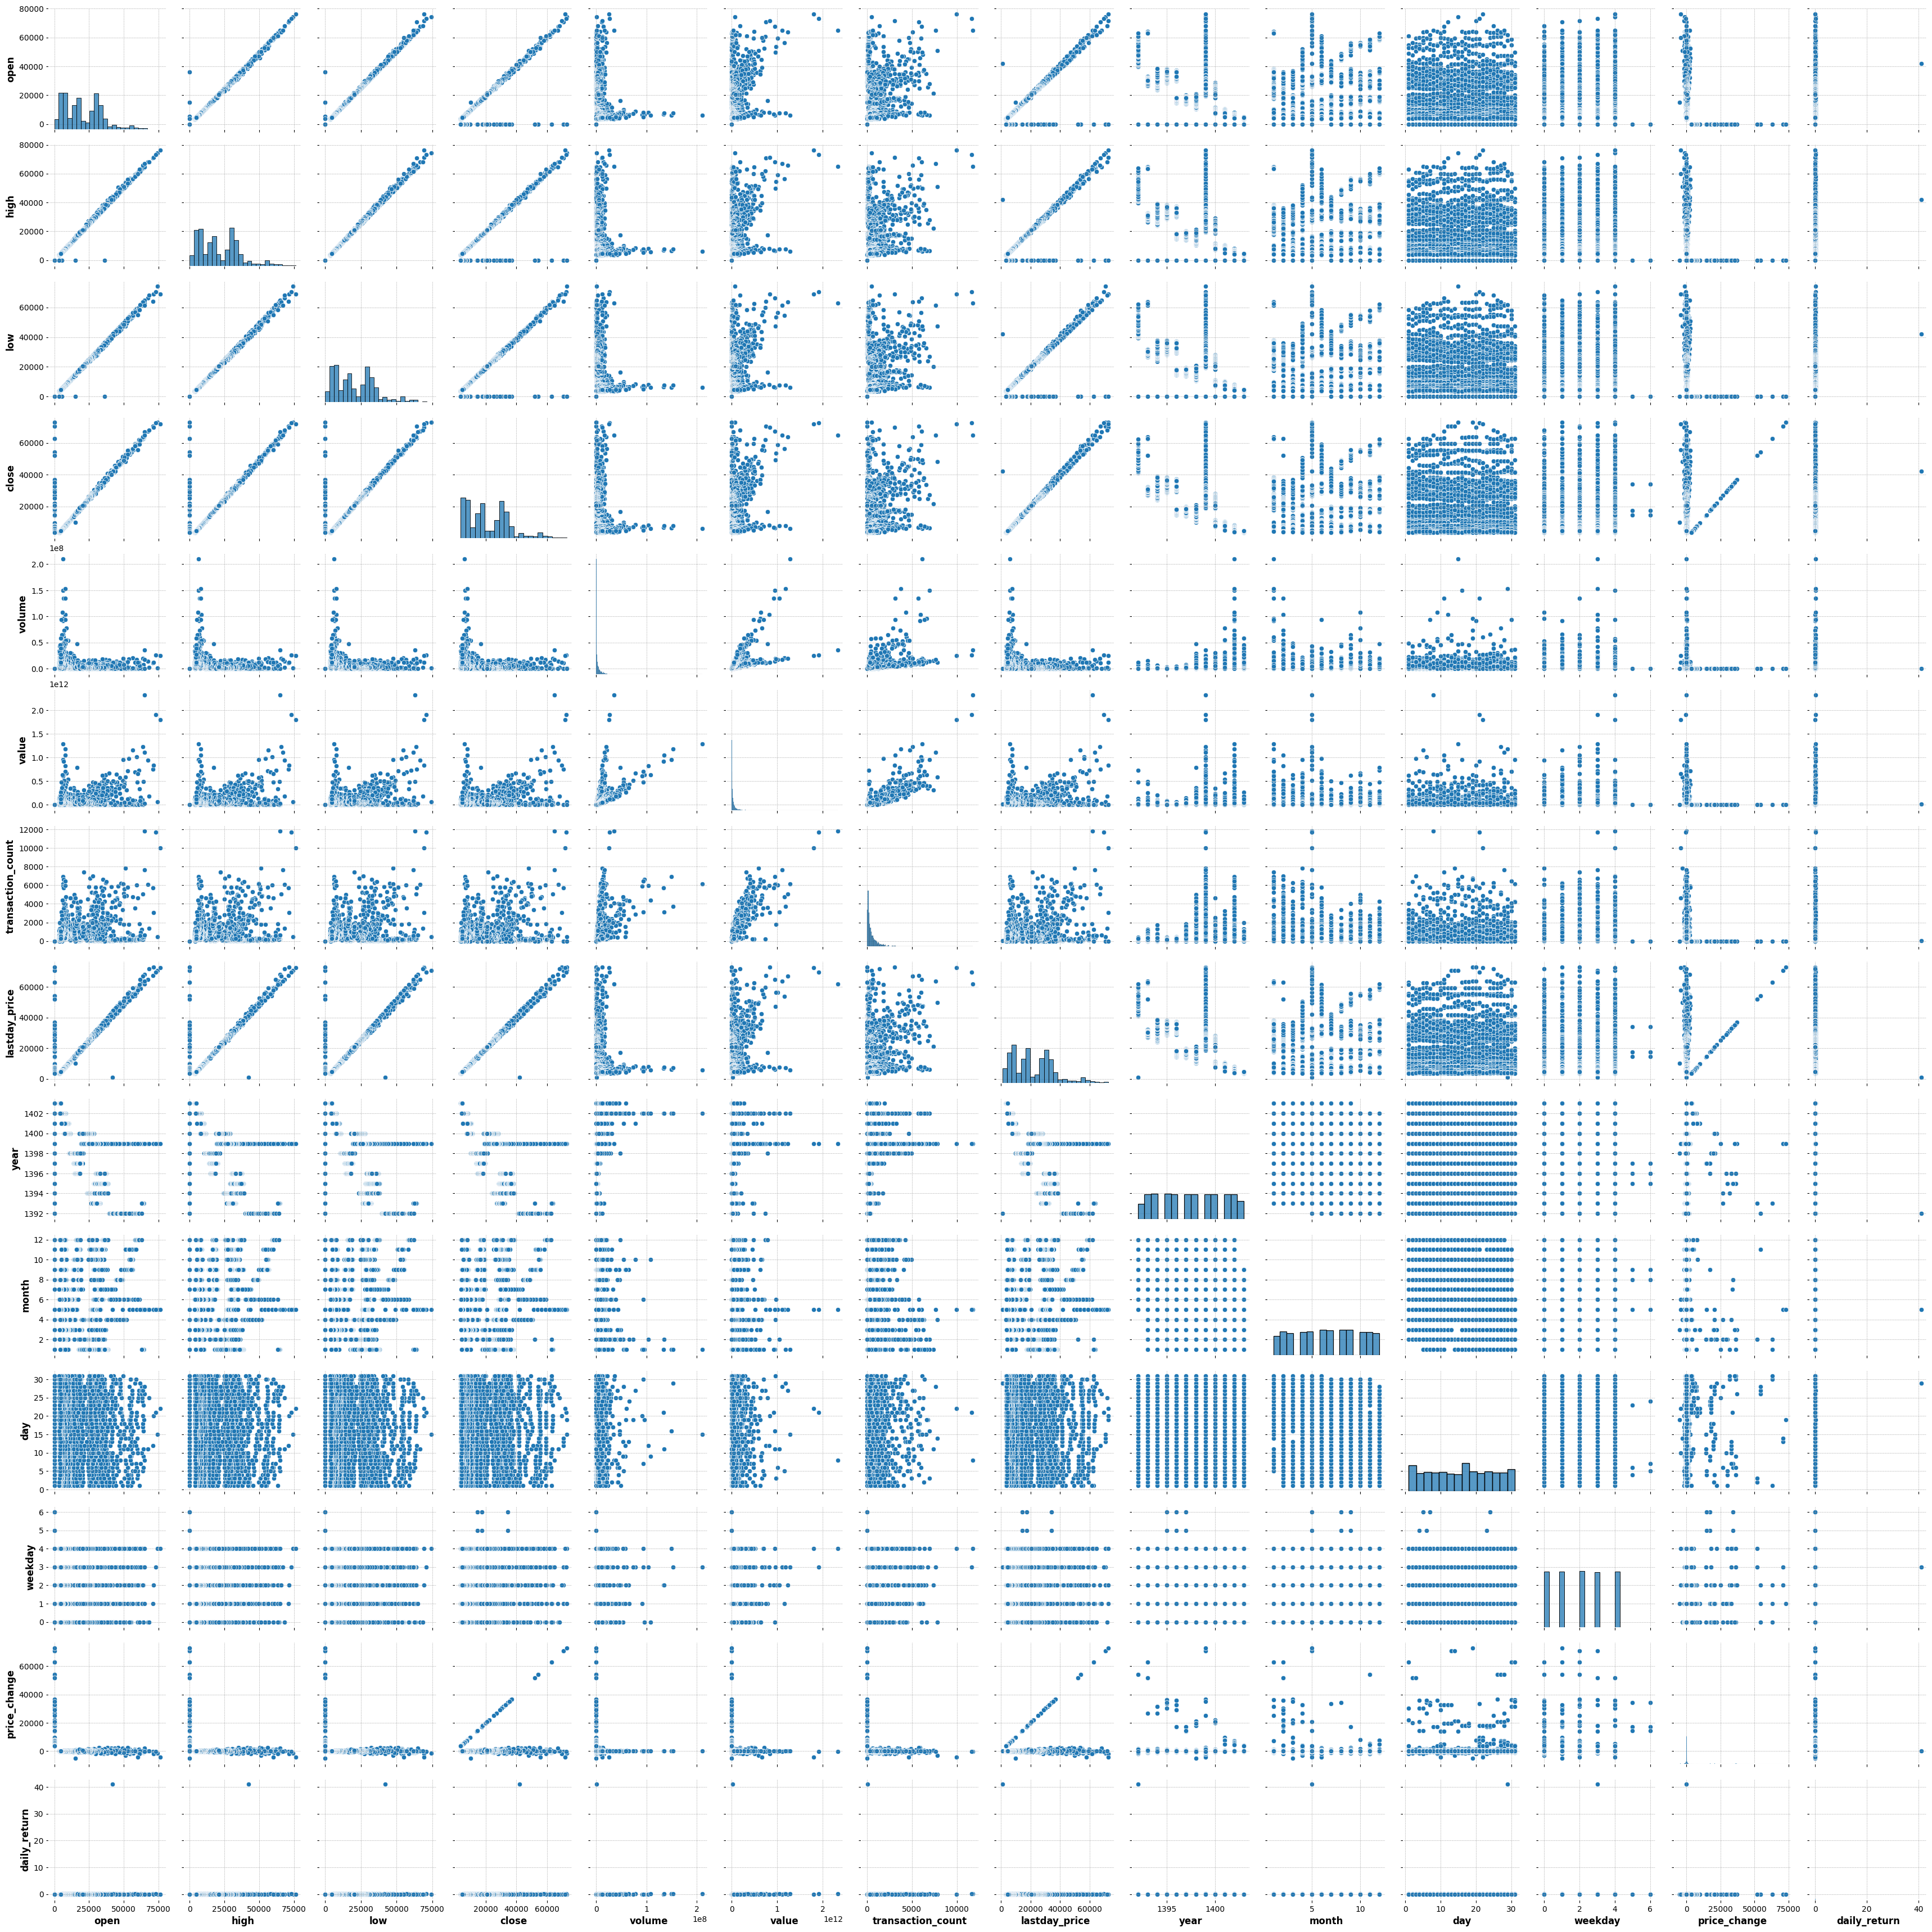

In [49]:
sns.pairplot(data=df)

In [50]:
# 2-find the most realted features to fill the missing values
corr = df.corr(numeric_only=True)
corr.style.background_gradient(cmap='coolwarm')


,open,high,low,close,volume,value,transaction_count,lastday_price,year,month,day,weekday,price_change,daily_return
open,1.000000,0.998202,0.998179,0.929164,-0.230625,0.168133,0.057422,0.927031,-0.718843,0.071863,-0.006271,0.004822,-0.219185,0.029100
high,0.998202,1.000000,0.999370,0.927990,-0.227755,0.172443,0.064133,0.925846,-0.715373,0.074033,-0.006914,0.005848,-0.217481,0.028721
low,0.998179,0.999370,1.000000,0.927968,-0.233675,0.157647,0.045264,0.925808,-0.724151,0.074928,-0.007576,0.005163,-0.217479,0.029857
close,0.929164,0.927990,0.927968,1.000000,-0.257984,0.143279,0.018129,0.997892,-0.747455,0.030322,0.000975,0.001480,0.157019,0.028329
volume,-0.230625,-0.227755,-0.233675,-0.257984,1.000000,0.643748,0.562895,-0.260144,0.400083,-0.098811,-0.004946,0.015515,-0.064780,-0.003169
value,0.168133,0.172443,0.157647,0.143279,0.643748,1.000000,0.846370,0.137756,0.223183,-0.099189,-0.003234,0.026805,-0.071017,-0.000672
transaction_count,0.057422,0.064133,0.045264,0.018129,0.562895,0.846370,1.000000,0.014458,0.327827,-0.115880,-0.004785,0.022372,-0.105559,-0.008203
lastday_price,0.927031,0.925846,0.925808,0.997892,-0.260144,0.137756,0.014458,1.000000,-0.745234,0.031432,0.000132,0.000915,0.157154,-0.028131
year,-0.718843,-0.715373,-0.724151,-0.747455,0.400083,0.223183,0.327827,-0.745234,1.000000,-0.105612,0.002868,-0.001118,-0.052354,-0.032625
month,0.071863,0.074033,0.074928,0.030322,-0.098811,-0.099189,-0.115880,0.031432,-0.105612,1.000000,-0.077022,0.002155,-0.111959,-0.009753


In [51]:
import plotly.graph_objects as go
fig = go.Figure(data=[go.Candlestick(
    x=df['Gregorian_Date'],
    open=df['open'],
    high=df['high'],
    low=df['low'],
    close=df['close']
)])

# Update layout for better visualization
fig.update_layout(
    title='Candlestick Chart of Stock Prices',
    xaxis_title='Date',
    yaxis_title='Price',
    xaxis_rangeslider_visible=False,  # Remove the range slider if not needed
    template='plotly_dark',           # Optional: Dark theme for better looks
)

# Show the chart
fig.show()